# The Signal Chain: From Resistance Change to Bridge Output
### *Modern Strain Gage Technology* — Companion Notebook

**The Wheatstone bridge is the analytical engine of every strain gage measurement.** It takes a resistance change too small to read directly — a few parts in ten thousand — and turns it into a voltage an amplifier can work with.

Companion notebook to Chapter 26 — The Signal Chain: From Resistance Change to Bridge Output.

Chapter 26 follows the signal from the deforming foil, through the solder joint and lead wires, into the four arms of the bridge. This notebook picks up the electrical end of that chain. It starts with the numbers behind the chapter's central claim — that a real, reliable resistance change is *almost impossible to measure directly* — and then compares the standard bridge configurations that turn that change into usable output. The configuration-comparison figure it generates is the one reproduced in Chapter 27 (Figure 27.4), where bridge selection is developed in full.

Two ideas run through the notebook. First, the **gage factor** links strain to fractional resistance change, and the bridge links that change to a voltage *ratio* — output per volt of excitation — so the same reading means the same strain regardless of supply voltage. Second, the familiar linear formulas (for a quarter bridge, $V_\text{out}/V_\text{ex} \approx \tfrac{1}{4}\,GF\,\varepsilon$) are approximations: the bridge is slightly **nonlinear**, and that nonlinearity grows with strain.

**This notebook demonstrates:**
1. The resistance change behind a strain measurement, and the quarter-bridge output it produces (Chapter 26).
2. Output voltage versus strain for the four standard bridge configurations — quarter, half-bridge bending, half-bridge Poisson, and full-bridge bending (Chapter 27, Figure 27.4).
3. The quarter-bridge nonlinearity error as a function of strain amplitude.

In [1]:
# Colab setup — install dependencies (no-op if already present):
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

In [2]:
# --- Measurement parameters (edit these to explore your own installation) ---
GAGE_FACTOR    = 2.07     # gage factor GF of a typical metallic foil gage (dimensionless)
V_EXCITATION_V = 5.0      # bridge excitation voltage V_ex (volts)
POISSON_RATIO  = 0.30     # Poisson's ratio nu of the test material (dimensionless)
R_NOMINAL_OHM  = 350.0    # nominal gage / arm resistance R (ohms)

# Strain sweep for the configuration and nonlinearity plots: 0 to 5000 microstrain,
# the upper end of the range seen in routine structural testing.
STRAIN_MAX = 5000e-6      # maximum strain (dimensionless; = 5000 microstrain)
N_POINTS   = 500
strain = np.linspace(0.0, STRAIN_MAX, N_POINTS)

# Figure output directory. DO NOT change this path or the saved filename below:
# Chapter 27 (Figure 27.4) includes the exact file produced by this notebook, so
# it is written into Chapter 27's media folder under a fig27_ name.
OUT_DIR = Path("../src/media/ch27")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Bridge output models. Each returns the absolute output V_out in volts (= ratio x V_ex).
# All follow the voltage-ratio equations of Chapters 26-27; x = GF*eps is the fractional
# resistance change of a single active gage.

def quarter_bridge_exact(eps, gf=GAGE_FACTOR, vex=V_EXCITATION_V):
    """Exact quarter-bridge output (one active gage), in volts.

    V_out/V_ex = (gf*eps) / (4 + 2*gf*eps)  -- Chapter 27, Eq. 27.4.
    The 2*gf*eps term in the denominator is the source of bridge nonlinearity.
    """
    return vex * gf * eps / (4.0 + 2.0 * gf * eps)


def quarter_bridge_linear(eps, gf=GAGE_FACTOR, vex=V_EXCITATION_V):
    """Linear (small-strain) quarter-bridge approximation, in volts.

    V_out/V_ex = (1/4)*gf*eps  -- Chapter 26, Eq. 26.3. Dropping the denominator's
    strain term slightly overstates the true output as strain grows.
    """
    return vex * gf * eps / 4.0


def half_bridge_bending(eps, gf=GAGE_FACTOR, vex=V_EXCITATION_V):
    """Bending half-bridge: two active gages, equal and opposite strain, in volts.

    Adjacent arms carry +eps and -eps, so V_out/V_ex = (1/2)*gf*eps
    -- Chapter 27, Eq. 27.1. The two arms' nonlinear terms cancel exactly,
    making this configuration ideally linear (no denominator strain term).
    """
    return vex * gf * eps / 2.0


def half_bridge_poisson(eps, gf=GAGE_FACTOR, vex=V_EXCITATION_V, nu=POISSON_RATIO):
    """Poisson half-bridge: one axial gage plus one transverse (Poisson) gage, in volts.

    The transverse gage reads -nu*eps, so the exact output is
    V_out/V_ex = gf*eps*(1 + nu) / (4 + 2*gf*eps*(1 - nu)).
    In the small-strain limit this reduces to (1/4)*gf*eps*(1 + nu)
    -- Chapter 27, Eq. 27.2. Like the quarter bridge, it stays nonlinear.
    """
    return vex * gf * eps * (1.0 + nu) / (4.0 + 2.0 * gf * eps * (1.0 - nu))


def full_bridge_bending(eps, gf=GAGE_FACTOR, vex=V_EXCITATION_V):
    """Bending full-bridge: four active gages, in volts.

    Arms 1,3 carry +eps and arms 2,4 carry -eps, giving V_out/V_ex = gf*eps
    -- Chapter 27, Eq. 27.3. Four times the quarter-bridge output and, like the
    bending half-bridge, ideally linear.
    """
    return vex * gf * eps


def quarter_bridge_nonlinearity_pct(eps, gf=GAGE_FACTOR):
    """Quarter-bridge nonlinearity eta as a percentage -- Chapter 27, Eq. 27.5.

    eta = (gf*eps) / (2 + gf*eps): the fraction by which the exact output falls
    short of the linear prediction. Rule of thumb: eta in percent is roughly the
    strain in percent. The shortfall means tensile strain reads low, compressive high.
    """
    return 100.0 * gf * eps / (2.0 + gf * eps)

---
## 1 — The Resistance Change and the Quarter-Bridge Output

Chapter 26 opens with a concrete number: a steel beam at 1,000 microstrain changes a bonded gage's resistance by a fraction of an ohm. The **gage factor** $GF$ sets that link,

$$\frac{\Delta R}{R} = GF \cdot \varepsilon,$$

which in words says the *fractional* change in resistance is simply the gage factor times the strain. For a 120 Ω gage the change is a couple of tenths of an ohm; for a 350 Ω gage, a bit more. Either way it is real, proportional, and far too small to read with an ordinary ohmmeter — which is exactly why the bridge exists.

The **quarter-bridge** puts that one active gage in a single arm and fills the other three with fixed resistors. Its output is a voltage *ratio*: for $GF = 2.0$, $V_\text{ex} = 5$ V, and $\varepsilon = 1{,}000\ \mu\varepsilon$, the bridge delivers about 2.5 mV — a ratio of 500 µV/V (Chapter 26). The cell below recomputes the resistance change and this output using the notebook's representative $GF = 2.07$, for both a 120 Ω and a 350 Ω gage; the results land within a few percent of the chapter's round-number values.

In [4]:
# Reproduce Chapter 26's resistance-change and quarter-bridge numbers at 1000 microstrain.
EPS_REF = 1000e-6  # reference strain used in Chapter 26's worked examples (= 1000 microstrain)

dR_over_R = GAGE_FACTOR * EPS_REF  # fractional resistance change, dR/R = GF * epsilon  (Eq. 26.1)
print(f"At {EPS_REF * 1e6:.0f} microstrain with GF = {GAGE_FACTOR}:")
print(f"  Fractional resistance change dR/R = {dR_over_R:.4f}  ({dR_over_R * 100:.2f} %)")
for R in (120.0, R_NOMINAL_OHM):
    print(f"  {R:.0f} ohm gage:  dR = {dR_over_R * R:.3f} ohm")

# Quarter-bridge output at the same strain. The output *ratio* is independent of R,
# so this holds for a 120 ohm or a 350 ohm gage alike.
v_qb = quarter_bridge_linear(EPS_REF)
print(f"\nQuarter-bridge output (V_ex = {V_EXCITATION_V} V):")
print(f"  V_out = {v_qb * 1e3:.3f} mV   =>   {v_qb / V_EXCITATION_V * 1e6:.0f} uV/V")

At 1000 microstrain with GF = 2.07:
  Fractional resistance change dR/R = 0.0021  (0.21 %)
  120 ohm gage:  dR = 0.248 ohm
  350 ohm gage:  dR = 0.724 ohm

Quarter-bridge output (V_ex = 5.0 V):
  V_out = 2.587 mV   =>   518 uV/V


---
## 2 — The Four Standard Bridge Configurations, and Quarter-Bridge Nonlinearity

The quarter bridge uses only one of the four arms. The other three configurations put more gages to work, and *how* they are arranged decides three things at once: sensitivity, temperature compensation, and which part of the strain field is measured versus rejected. The figure below plots output against strain for the four standard configurations Chapter 27 develops — and it is the exact figure reproduced there as Figure 27.4. Each configuration has its own line style and marker as well as its colour, so the curves stay distinguishable in the black-and-white softcover.

- **Quarter-bridge** (one active gage): the baseline, $V_\text{out}/V_\text{ex} = \tfrac{1}{4}\,GF\,\varepsilon$. Shown both exact and linear so the small gap between them is visible.
- **Half-bridge, bending** (two active gages, equal and opposite strain): $\tfrac{1}{2}\,GF\,\varepsilon$ — double the output, axial load rejected, and *ideally linear* because the two arms' nonlinear terms cancel.
- **Half-bridge, Poisson** (one axial gage, one transverse gage reading $-\nu\varepsilon$): $\tfrac{1}{4}\,GF\,\varepsilon(1+\nu)$ — about $(1+\nu)$ times the quarter-bridge output, with first-order temperature compensation. It remains nonlinear.
- **Full-bridge, bending** (four active gages): $GF\,\varepsilon$ — four times the quarter-bridge output, full common-mode rejection, and ideally linear.

The right panel isolates the **quarter-bridge nonlinearity** $\eta$ — the fraction by which the exact output falls short of the linear prediction (Chapter 27, Eq. 27.5). It grows with strain: about 0.1 % at 1,000 µε and about 0.5 % at 5,000 µε. The rule of thumb is that $\eta$ in percent roughly equals the strain in percent. Direction matters too: this shortfall means a quarter bridge reads tensile strain slightly *low* and compressive strain slightly *high*. The bending and full-bridge configurations do not share this error — their opposing arms keep the bridge currents symmetric, so their nonlinear terms cancel.

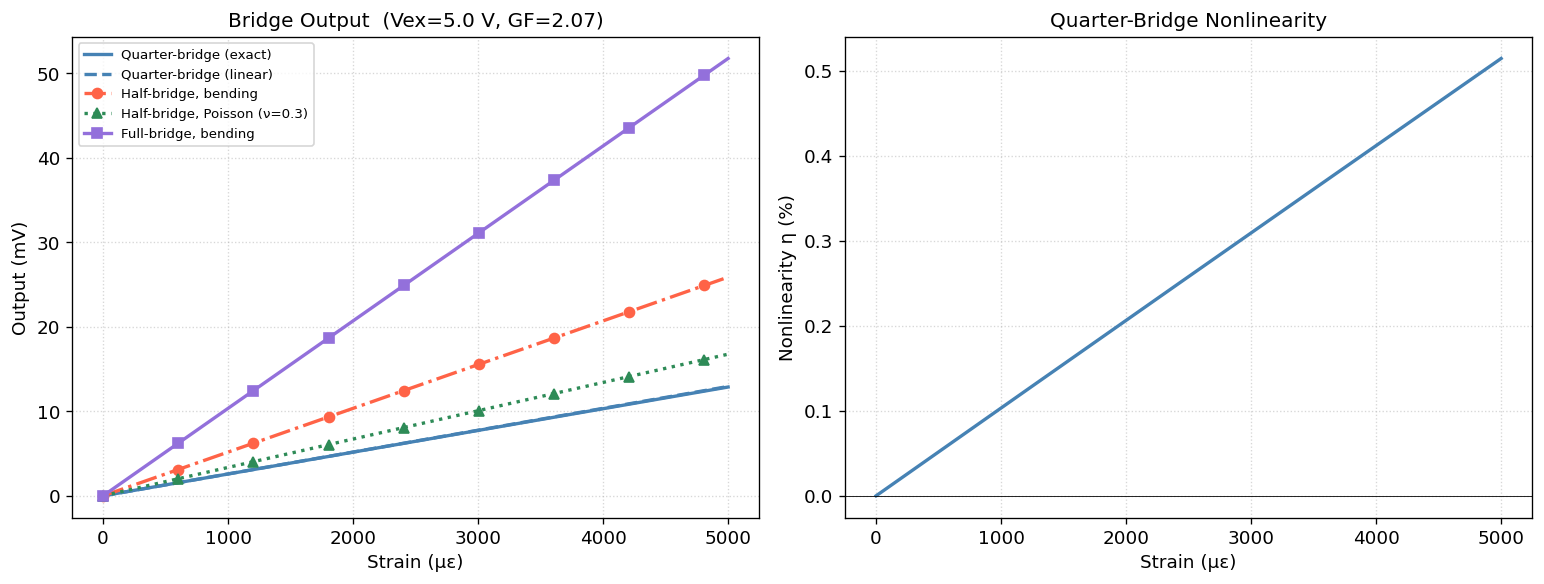

At ε=1000 με  (Vex=5.0 V, GF=2.07):
  Quarter-bridge (exact)    :  2.5848 mV  (0.5170 mV/V)
  Quarter-bridge (linear)   :  2.5875 mV  (0.5175 mV/V)
  Half-bridge, bending      :  5.1750 mV  (1.0350 mV/V)
  Half-bridge, Poisson (ν=0.3):  3.3613 mV  (0.6723 mV/V)
  Full-bridge, bending      : 10.3500 mV  (2.0700 mV/V)


In [5]:
# Left panel: output vs strain for the four standard configurations.
# Right panel: quarter-bridge nonlinearity vs strain. This saved figure is Chapter 27, Fig. 27.4.
strain_ue = strain * 1e6  # strain in microstrain for the x-axis

# (function, legend label, color, linestyle, marker)
# Line style + marker give every series a non-colour cue for the B&W softcover.
configurations = [
    (quarter_bridge_exact,  'Quarter-bridge (exact)',                  'steelblue',    '-',  None),
    (quarter_bridge_linear, 'Quarter-bridge (linear)',                 'steelblue',    '--', None),
    (half_bridge_bending,   'Half-bridge, bending',                    'tomato',       '-.', 'o'),
    (half_bridge_poisson,   f'Half-bridge, Poisson (ν={POISSON_RATIO})', 'seagreen',   ':',  '^'),
    (full_bridge_bending,   'Full-bridge, bending',                    'mediumpurple', '-',  's'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for func, label, color, style, marker in configurations:
    axes[0].plot(strain_ue, func(strain) * 1e3, color=color, lw=2, linestyle=style,
                 marker=marker, markevery=60, ms=6, label=label)
axes[0].set_xlabel('Strain (με)')
axes[0].set_ylabel('Output (mV)')
axes[0].set_title(f'Bridge Output  (Vex={V_EXCITATION_V} V, GF={GAGE_FACTOR})')
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(strain_ue, quarter_bridge_nonlinearity_pct(strain), color='steelblue', lw=2)
axes[1].set_xlabel('Strain (με)')
axes[1].set_ylabel('Nonlinearity η (%)')
axes[1].set_title('Quarter-Bridge Nonlinearity')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig27_nb1_bridge_output_configurations.png', bbox_inches='tight', dpi=150)
plt.show()

# Numerical summary at the Chapter 26 reference strain (1000 microstrain).
print(f"At ε={EPS_REF * 1e6:.0f} με  (Vex={V_EXCITATION_V} V, GF={GAGE_FACTOR}):")
for func, label, *_ in configurations:
    v = func(EPS_REF)
    print(f"  {label:26s}: {v * 1e3:7.4f} mV  ({v / V_EXCITATION_V * 1e3:.4f} mV/V)")

---
## Where to take this next

The configurations above are the starting point, not the destination. Three concrete extensions:

1. **Add the lead-wire penalty.** Chapter 26 shows that a two-wire quarter bridge in the field is dominated by lead resistance. Model a lead run of resistance $R_L$ in series with the gage arm, and plot the resulting initial imbalance (in µε) and the sensitivity loss — *desensitization* — as a function of lead length for both a 120 Ω and a 350 Ω gage. Then add the three-wire correction and show the lead-temperature error cancelling in adjacent arms.
2. **Correct the nonlinearity, then check it.** Implement Chapter 27's correction $\varepsilon = 2\varepsilon_i / (2 - GF\,\varepsilon_i \times 10^{-6})$ that recovers true strain from an indicated quarter-bridge reading. Verify numerically that feeding it the strain implied by `quarter_bridge_exact` returns the strain you started with — at 1,000, 15,000, and 100,000 µε — and confirm the tension/compression asymmetry the chapter describes.
3. **Sweep the material and excitation.** Re-plot the configuration comparison across Poisson ratios (aluminum ≈ 0.33, steel ≈ 0.285, titanium ≈ 0.31) and excitation voltages, and quantify how much output each configuration gains. This is a first step toward the sensitivity-versus-self-heating trade-off developed in later chapters, where higher excitation buys signal at the cost of gage heating.